Generated entirely by claude - iteratively to check

# Condensed QA-flag summary figures (per-flag, not composited)

This notebook reduces the per-pixel-day QA flags (dims: scenario x ensemble member x
variable x day x lat x lon) down to a manageable set of maps, time series, and tables --
one flag at a time, never OR'd together into a composite.

It reads from the **intermediate per-tag flag stores** written by
`flag_step2_generate-intermediate-qa-flags.ipynb`
(`get_intermediate_flags`, one icechunk repo per `{gcm}_{var}_{scenario}_{ens}_{method}` tag),
*not* the final combined store written by `flag_step3_combine_and_write_to_source_coop.ipynb` --
that final store only contains the two OR'd composite flags
(`qa_flag_time_varying` / `qa_flag_time_invariant`), which is exactly what we don't want here.

## Design: compute once, cache to CACHE_DIR, plot from the cache

Every analysis cell below is split into two phases:

1. **Compute** cells that touch the raw flag arrays via dask, reduce them down to small
   maps/time-series/tables, and cache each result to `CACHE_DIR` as soon as it's computed.
   `CACHE_DIR` is an `s3://` prefix, not local disk -- the per-combo pickles add up to
   roughly 10GB (see the Hovmoller section below for why), too much to write locally on a
   temporary/small-disk remote machine.
2. **Plot** cells (bottom half of the notebook) that only ever read from the small cached
   results in memory. They never re-touch dask or icechunk.

So if you come back later to change a label, colormap, or colorbar, you only need to
re-run the plotting cells -- and if you restart the kernel entirely, re-running the
compute cells from the top is cheap too, since `compute_or_load` skips any combo that's
already cached in `CACHE_DIR` and just unpickles it.

Before committing to the full run (every flag x variable x scenario, the expensive part),
there's a **Quick preview** section that computes and plots just one flag/variable so you
can confirm the analysis is heading the direction you want. Nothing it computes is
wasted: it's cached the same way as everything else, so the full run's compute loop just
reloads it instead of recomputing.

## Chunk-size-informed scope

Flags are stored `uint8` on a global 0.25 deg grid (720 lat x 1440 lon), chunked
`(365 time, 36 lat, 72 lon)` / sharded `(1095 time, 180 lat, 360 lon)`. Reductions over a
whole axis (time, space, or lon-only) are cheap, chunk-aligned tree-reductions -- that
covers every figure below. The one thing we're intentionally *not* computing here is a
longest-consecutive-flagged-run ("persistence") map: that needs an ordered scan along
time rather than a plain reduction, and it's ambiguous across the historical / ssp245 /
g6_1p5k / g6_1p5k_end scenario breaks anyway. Worth doing later, targeted, only on
specific flag/variable/scenario cells that these figures flag as suspicious.


In [1]:
import pickle
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import dask
import fsspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rusterize as _rusterize_pkg
import xarray as xr
from dask.distributed import Client, LocalCluster
from matplotlib.colors import ListedColormap
from rasterix.rasterize import geometry_mask

from srm import catalog
from srm.qa_flags import (
    FLAG_LIST_TIME_INVARIANT,
    FLAG_LIST_TIME_VARYING,
    INPUT_CHUNKS,
    discover_leaves,
    get_intermediate_flags,
    parse_tag,
)

In [2]:
# --- Run parameters ---------------------------------------------------------
# Must match the run that produced the intermediate per-tag flag stores -- see
# flag_step2_generate-intermediate-qa-flags.ipynb for the same values.
GCMS = ["CESM2-WACCM"]
VARIABLES = ["tas", "tasmax", "tasmin", "pr", "rsds"]

BRANCH = "pr-638-global"  # branch of the raw/debiased data trees, used only to discover tags
ROOT_DIR = "s3://carbonplan-srm/scratch/output/qa/"
STORE_SUBSET_ID = "global"

FLAG_BUCKET = "carbonplan-srm"
FLAG_PREFIX = "scratch/output/qa-intermediate-flags"  # where get_intermediate_flags reads from

SCENARIO_ORDER = ["historical", "ssp245", "g6_1p5k", "g6_1p5k_end"]

CACHE_DIR = (
    "s3://carbonplan-srm/scratch/intermediate_qa_flag"  # per-combo compute results (pkl -- large)
)

FIGURE_DIR = Path("./qa_condensed_figures")  # saved PNGs of every figure this notebook makes
FIGURE_DIR.mkdir(exist_ok=True)

N_IO_THREADS = 32  # concurrent "open icechunk store" calls -- separate from dask's own parallelism

# Local distributed cluster, sized for one 64-cpu / 250GB machine -- see the markdown note
# just above the cluster-startup cell below for why this replaced a plain scheduler="threads"
# config. Tune DASK_N_WORKERS x DASK_MEMORY_LIMIT_PER_WORKER to stay comfortably under your
# machine's actual RAM (defaults below: 8 x 24GB = 192GB, leaving ~58GB of headroom).
DASK_N_WORKERS = 8
DASK_THREADS_PER_WORKER = 8
DASK_MEMORY_LIMIT_PER_WORKER = "24GB"

## Dask cluster

**If Compute pass 1 previously died with a memory error, this cell is the fix.** The plain
`dask.config.set(scheduler="threads")` this notebook used to set up here has no memory
awareness: it greedily starts every ready task as soon as a thread is free, with no regard
for how much intermediate (chunk-read, decompressed, not-yet-reduced) data is sitting in
RAM. On a wide reduction graph -- and `historical` alone is ~60,225 days, i.e. up to
~66,000 zarr chunks per ensemble member at the on-disk `(365, 36, 72)` chunk size -- that
scheduler can end up holding far more decompressed chunks in flight at once than the
reduction actually needs, with no back-pressure and nowhere to spill. That's almost
certainly what ran the machine out of memory.

A local `distributed` cluster fixes both halves of this:
- its scheduler is memory-aware and prioritizes finishing in-progress reduction branches
  over greedily starting new ones, so peak memory stays bounded near the workers' limits
  instead of growing with graph width;
- each worker gets a hard `memory_limit` and spills to disk automatically as it approaches
  it, so a bad combo degrades (slower) instead of crashing the kernel.

The `_open_flags` cell below also now explicitly rechunks every flag array to
`INPUT_CHUNKS` (the same shard-aligned `(1095, 180, 360)` chunking `discover_leaves`
already uses for the raw data trees) right after opening it, instead of relying on
`xr.open_zarr`'s default chunk selection -- that bounds each chunk at a known, sane size
and cuts the historical-scenario graph from ~66,000 chunks/member down to ~880.

In [ ]:
cluster = LocalCluster(
    n_workers=DASK_N_WORKERS,
    threads_per_worker=DASK_THREADS_PER_WORKER,
    memory_limit=DASK_MEMORY_LIMIT_PER_WORKER,
)
client = Client(cluster)
client

In [4]:
# CACHE_DIR is an s3:// prefix -- this notebook runs on a temporary remote machine with no
# room for ~10GB of local pkl cache. url_to_fs resolves the filesystem once (credentials,
# protocol) instead of on every one of the ~100 compute_or_load calls below.
_cache_fs, _cache_root = fsspec.core.url_to_fs(CACHE_DIR)


def _cache_path(key: str) -> str:
    return f"{_cache_root}/{key.replace('/', '__')}.pkl"


def compute_or_load(key: str, compute_fn):
    """Compute once, cache to CACHE_DIR, and reuse on every later run (incl. after a kernel restart).

    Safe to call repeatedly: a cache hit is just a pickle load from S3, no dask/icechunk touched.
    """
    path = _cache_path(key)
    if _cache_fs.exists(path):
        with _cache_fs.open(path, "rb") as f:
            return pickle.load(f)
    result = compute_fn()
    with _cache_fs.open(path, "wb") as f:
        pickle.dump(result, f)
    return result

## Discover tags and open every intermediate flag store

`discover_leaves` enumerates every `(gcm, scenario, variable, ensemble, method)` leaf by
opening the raw/debiased data trees -- this is metadata-only (no data is loaded), it just
tells us which tags exist. We then open each tag's intermediate flag store in parallel
threads (also metadata-only: it just registers the zarr group's variables, lazily).

In [ ]:
[
    trees,
    tags,
    gcms_np,
    scenarios_np,
    variables_np,
    tags_np,
    methods_np,
    debiased_coarse_flags_np,
] = discover_leaves(gcms=GCMS, branch=BRANCH, root_dir=ROOT_DIR, store_subset_id=STORE_SUBSET_ID)

tag_meta = pd.DataFrame(
    {
        "tag": tags,
        "gcm": gcms_np,
        "variable": variables_np,
        "scenario": scenarios_np,
        "method": methods_np,
        "ensemble_member": [parse_tag(t)[3] for t in tags],
    }
)
tag_meta = tag_meta[tag_meta["variable"].isin(VARIABLES)].reset_index(drop=True)
print(f"{len(tag_meta)} tags to open")
tag_meta.head()

opened 1/1 stores on branch 'pr-638-global': CESM2-WACCM
196 leaves across 1 GCMs
71 tags to open


/scratch/synced/src/srm/qa_flags.py:636: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 180. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)
/scratch/synced/src/srm/qa_flags.py:636: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 360. This could degrade performance. Instead, consider rechunking after loading.
  trees[gcm] = xr.open_datatree(session.store, engine="zarr", chunks=INPUT_CHUNKS)


,tag,gcm,variable,scenario,method,ensemble_member
0,CESM2-WACCM_pr_g6_1p5k_001_qdmsd,CESM2-WACCM,pr,g6_1p5k,qdmsd,001
1,CESM2-WACCM_pr_g6_1p5k_002_qdmsd,CESM2-WACCM,pr,g6_1p5k,qdmsd,002
2,CESM2-WACCM_pr_g6_1p5k_003_qdmsd,CESM2-WACCM,pr,g6_1p5k,qdmsd,003
3,CESM2-WACCM_rsds_g6_1p5k_002_qdmsd,CESM2-WACCM,rsds,g6_1p5k,qdmsd,002
4,CESM2-WACCM_rsds_g6_1p5k_001_qdmsd,CESM2-WACCM,rsds,g6_1p5k,qdmsd,001


In [6]:
def _open_flags(tag):
    ds = get_intermediate_flags(tag=tag, bucket=FLAG_BUCKET, prefix=FLAG_PREFIX)
    # Rechunk to the same shard-aligned layout discover_leaves uses for the raw data trees,
    # instead of trusting xr.open_zarr's default chunk selection -- see the "Dask cluster"
    # note above for why an unbounded/misaligned chunking is the likely OOM culprit.
    rechunk = {dim: size for dim, size in INPUT_CHUNKS.items() if dim in ds.sizes}
    return tag, ds.chunk(rechunk)


flag_datasets = {}
open_errors = {}
with ThreadPoolExecutor(max_workers=N_IO_THREADS) as pool:
    futures = {pool.submit(_open_flags, tag): tag for tag in tag_meta["tag"]}
    for future in as_completed(futures):
        tag = futures[future]
        try:
            _, ds = future.result()
            flag_datasets[tag] = ds
        except Exception as exc:  # noqa: BLE001 -- report every failure, don't stop at the first
            open_errors[tag] = f"{type(exc).__name__}: {exc}"

for tag, err in open_errors.items():
    print(f"FAILED to open intermediate flags for {tag}: {err}")

print(f"opened {len(flag_datasets)}/{len(tag_meta)} intermediate flag stores")

opened 71/71 intermediate flag stores


## Land mask and area weights

Same coastline-rasterization approach as `flag_step4_evaluate_flag_prevalence.ipynb`
(including its `rusterize` patch), computed once and reused everywhere below -- both for
land-only scalar stats in the summary table, and as `cos(lat)` area weights when
collapsing a Hovmoller array down to a single global time series.

The `rusterize` patch only takes effect in *this* process: it mutates the `rusterize`
module object in memory here, but the notebook now runs its dask work on a distributed
`LocalCluster` (see the "Dask cluster" section above), whose workers are separate
processes that import their own unpatched copy of `rusterize`. `geometry_mask` picks
between an eager, in-process path and a lazy, dask-`map_blocks` path based on whether its
template array is already in memory (`rasterix.rasterize.utils.is_in_memory`, literally
`not obj.chunks`) -- and our template is a rechunked, still-lazy flag array, so it would
take the lazy path and get rasterized on an unpatched worker, raising exactly the "`res`
and `out_shape` are mutually exclusive" error the patch exists to prevent. Loading the
tiny (720x1440x1 byte) template into memory *before* building it forces the eager,
in-process path instead, where the patch applies.

In [7]:
_original_rusterize = _rusterize_pkg.rusterize


def _rusterize_patched(*args, **kwargs):
    if kwargs.get("res") is not None and kwargs.get("out_shape") is not None:
        kwargs = dict(kwargs)
        kwargs.pop("res")
    return _original_rusterize(*args, **kwargs)


_rusterize_pkg.rusterize = _rusterize_patched

ocean_mask_geoparquet = catalog.get("ocean-mask")

_template_tag = tag_meta["tag"].iloc[0]
target_grid_da = flag_datasets[_template_tag][FLAG_LIST_TIME_VARYING[0]]
if "time" in target_grid_da.dims:
    target_grid_da = target_grid_da.isel(time=0, drop=True)
target_grid_da = (
    target_grid_da.compute()
)  # force in-memory so geometry_mask runs eagerly, in-process

# rusterize requires lat sorted descending
template = target_grid_da.sortby("lat", ascending=False).proj.assign_crs(spatial_ref="epsg:4326")
land_mask = ~geometry_mask(
    template,
    ocean_mask_geoparquet.to_geodataframe()[["geom"]],
    all_touched=True,
    engine="rusterize",
    xdim="lon",
    ydim="lat",
).drop_vars("spatial_ref", errors="ignore")
land_mask = land_mask.load().astype(np.uint8)

# cos(lat) area weights, normalized to mean 1 so a weighted mean is just (x * w).sum() / w.sum()
lat_weights = np.cos(np.deg2rad(land_mask["lat"]))
lat_weights = lat_weights / lat_weights.mean()

## Build the flag x variable x scenario catalog

Two catalogs, one per flag structure:

- **Time-varying** flags (`FLAG_LIST_TIME_VARYING`, dims `time, lat, lon`): one combo per
  `(flag_name, gcm, variable, scenario)`, with every ensemble member's tag attached.
- **Time-invariant** flags (`FLAG_LIST_TIME_INVARIANT`, dims `lat, lon`): these come from
  an ensemble-mean scenario-pair comparison, and `flag_step2` writes the *identical* map
  redundantly into every ensemble member of **both** scenarios in the comparison (see its
  "Write out flags" cell). So one combo per `(flag_name, gcm, variable)`, pointing at a
  single representative tag -- reading every duplicate copy would just rescan identical
  data for no benefit.

This is all cheap bookkeeping (pandas groupby over already-opened, still-lazy datasets) --
none of it touches dask.compute() -- so it runs in full here rather than being restricted
to the quick-preview subset below.

In [ ]:
time_varying_combos = []
for flag_name in FLAG_LIST_TIME_VARYING:
    for (gcm, var, scenario), group in tag_meta.groupby(["gcm", "variable", "scenario"]):
        member_tags = [
            t
            for t in group["tag"]
            if t in flag_datasets and flag_name in flag_datasets[t].data_vars
        ]
        if member_tags:
            time_varying_combos.append(
                {
                    "flag_name": flag_name,
                    "gcm": gcm,
                    "variable": var,
                    "scenario": scenario,
                    "member_tags": member_tags,
                }
            )

print(f"{len(time_varying_combos)} (flag x gcm x variable x scenario) time-varying combos")

47 (flag x gcm x variable x scenario) time-varying combos


In [ ]:
time_invariant_combos = []
seen = set()
for flag_name in FLAG_LIST_TIME_INVARIANT:
    for (gcm, var), group in tag_meta.groupby(["gcm", "variable"]):
        key = (flag_name, gcm, var)
        if key in seen:
            continue
        rep_tag = next(
            (
                t
                for t in group["tag"]
                if t in flag_datasets and flag_name in flag_datasets[t].data_vars
            ),
            None,
        )
        if rep_tag is not None:
            time_invariant_combos.append(
                {"flag_name": flag_name, "gcm": gcm, "variable": var, "representative_tag": rep_tag}
            )
            seen.add(key)

print(f"{len(time_invariant_combos)} (flag x gcm x variable) time-invariant combos")

24 (flag x gcm x variable) time-invariant combos


## Helper functions (compute + plot)

Everything in this section only *defines* functions -- nothing here calls
`dask.compute()` or touches the flag stores by itself. They're defined once, up front, and
used by both the Quick preview right after and the Full run further down, so the two
sections can't drift out of sync with each other.

### Time-varying combo compute

For each combo, every member's **time-mean map** (frac of days flagged per pixel),
**lon-mean Hovmoller** (time x lat), and land/global **scalar rates** are built as lazy
dask expressions from the *same* underlying `xr.DataArray` and handed to a single
`dask.compute()` call together. Dask dedupes shared graph nodes automatically, so each
chunk is only read and decompressed once per combo no matter how many of these outputs
depend on it -- that's what avoids duplicating the expensive part of the analysis across
the map / agreement-map / time-series / Hovmoller / table figures that all ultimately
come from this one pass.

Ensemble members are concatenated and reduced (mean, and fraction-of-members-flagged for
agreement) *after* this compute call, so only the small ensemble-mean/agreement arrays --
not every member's individual map/Hovmoller -- end up in the cache.

In [10]:
def _combo_key(c):
    return f"tv__{c['flag_name']}__{c['gcm']}__{c['variable']}__{c['scenario']}"


def _compute_time_varying_combo(combo):
    member_arrays = {
        parse_tag(t)[3]: flag_datasets[t][combo["flag_name"]] for t in combo["member_tags"]
    }

    lazy = {}
    for ens, da in member_arrays.items():
        lazy[("map", ens)] = da.mean(dim="time")  # frac of days flagged, per pixel
        lazy[("hovmoller", ens)] = da.mean(dim="lon")  # (time, lat), lon-averaged
        lazy[("scalar_total", ens)] = da.mean()  # frac of all pixel-days flagged
        lazy[("scalar_any", ens)] = (da.sum(dim="time") > 0).mean()  # frac of pixels ever flagged
        land_da = da.where(land_mask > 0)
        lazy[("scalar_total_land", ens)] = land_da.mean()
        lazy[("scalar_any_land", ens)] = (land_da.sum(dim="time") > 0).mean()

    keys = list(lazy.keys())
    values = dask.compute(*[lazy[k] for k in keys])
    computed = dict(zip(keys, values, strict=True))

    ens_list = list(member_arrays)
    ens_index = pd.Index(ens_list, name="ensemble_member")
    maps = xr.concat([computed[("map", e)] for e in ens_list], dim=ens_index)
    hovmollers = xr.concat([computed[("hovmoller", e)] for e in ens_list], dim=ens_index)

    per_member_table = pd.DataFrame(
        {
            "ensemble_member": ens_list,
            "frac_flagged": [float(computed[("scalar_total", e)]) for e in ens_list],
            "frac_space_ever_flagged": [float(computed[("scalar_any", e)]) for e in ens_list],
            "frac_flagged_land": [float(computed[("scalar_total_land", e)]) for e in ens_list],
            "frac_space_ever_flagged_land": [
                float(computed[("scalar_any_land", e)]) for e in ens_list
            ],
        }
    )

    return {
        "ensemble_mean_map": maps.mean(dim="ensemble_member"),
        "agreement_map": (maps > 0).mean(dim="ensemble_member"),
        "ensemble_mean_hovmoller": hovmollers.mean(dim="ensemble_member"),
        "per_member_table": per_member_table,
    }

### Time-invariant combo compute

Each of these is already a single `(lat, lon)` map (no time dimension, no ensemble
dimension -- see the catalog note above), so there's nothing to batch across members;
this is just a direct load plus two scalar rates per combo.

In [11]:
def _ti_combo_key(c):
    return f"ti__{c['flag_name']}__{c['gcm']}__{c['variable']}"


def _compute_time_invariant_combo(combo):
    da = flag_datasets[combo["representative_tag"]][combo["flag_name"]]
    (arr,) = dask.compute(da)
    return {
        "map": arr,
        "frac_flagged": float(arr.mean()),
        "frac_flagged_land": float(arr.where(land_mask > 0).mean()),
    }

### Derived helpers (cheap -- operate on already-cached, already-reduced arrays)

`hovmoller_to_timeseries` collapses a cached `(time, lat)` Hovmoller array down to a
single area-weighted global time series. It's deliberately *not* land-masked: the
Hovmoller pass above already averaged over all of `lon` (land + ocean mixed), so a
land-only time series would need its own separate masked lon-reduction pass -- not worth
doubling pass-2's cost for what the land-only *scalar* rates in the table already cover.
The scenario-boundary zoom just slices this same time series around the g6_1p5k ->
g6_1p5k_end splice, no extra computation needed.

In [12]:
def hovmoller_to_timeseries(hovmoller):
    """Area-weighted (cos-lat) collapse of a (time, lat) Hovmoller array to a time series."""
    return (hovmoller * lat_weights).sum(dim="lat") / lat_weights.sum(dim="lat")


def top_n_pixels(map_da, n=15):
    flat = map_da.stack(pixel=("lat", "lon"))
    top = flat.sortby(flat, ascending=False).isel(pixel=slice(0, n))
    return pd.DataFrame(
        {
            "lat": top["lat"].values,
            "lon": top["lon"].values,
            "value": top.values,
        }
    )

### Plot style and helpers

`PLOT_STYLE` centralizes labels/colormaps/sizing so restyling a figure later means
editing one dict plus the relevant `plot_*` function, not hunting through every
figure-generating loop. `plot_summary_heatmap` reads the `summary_df` table built in the
Full run section below, so it's defined here but only usable once that section has run.

In [13]:
PLOT_STYLE = {
    "cmap_map": "Reds",
    "cmap_agreement": "Purples",
    "cmap_hovmoller": "Reds",
    "cmap_invariant": "Oranges",
    "zero_color": "0.85",  # flat gray for confirmed-zero pixels, distinct from any cmap's range
    "figsize_map": (7, 4.5),
    "figsize_grid_cell": (
        3.2,
        2.5,
    ),  # taller than the map itself to leave room for each panel's colorbar
    "coastline_linewidth": 0.4,
    "coastline_edgecolor": "0.3",
    "title_fontsize": 10,
    "suptitle_fontsize": 12,
}

In [ ]:
_FIELD_CBAR_LABELS = {
    "ensemble_mean_map": "ensemble-mean fraction of days flagged",
    "agreement_map": "fraction of ensemble members flagged",
}


def plot_map(map_da, title, ax=None, cmap=None, vmin=0, vmax=None, cbar_label="fraction flagged"):
    own_fig = ax is None
    if own_fig:
        plt.figure(figsize=PLOT_STYLE["figsize_map"])
        ax = plt.subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Flat "zero" color for real (non-NaN) pixels that are exactly 0, plotted *underneath* the
    # colormap layer below -- without this, a confirmed-zero pixel and a genuinely missing/NaN
    # one both render as blank background and are impossible to tell apart.
    zero_mask = map_da.notnull() & (map_da == 0)
    xr.where(zero_mask, 1, np.nan).plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=ListedColormap([PLOT_STYLE["zero_color"]]),
        vmin=0,
        vmax=1,
        add_colorbar=False,
    )

    plot_da = map_da.where(map_da > 0)
    im = plot_da.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap or PLOT_STYLE["cmap_map"],
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
    )
    ax.add_feature(
        cfeature.COASTLINE,
        linewidth=PLOT_STYLE["coastline_linewidth"],
        edgecolor=PLOT_STYLE["coastline_edgecolor"],
    )
    ax.set_title(title, fontsize=PLOT_STYLE["title_fontsize"])
    plt.colorbar(im, ax=ax, orientation="horizontal", pad=0.05, label=cbar_label, shrink=0.85)
    if own_fig:
        plt.tight_layout()
    return im


def plot_flag_grid(
    flag_name, gcm, field="ensemble_mean_map", variables=None, scenarios=None, cmap=None
):
    variables = variables or VARIABLES
    scenarios = scenarios or SCENARIO_ORDER
    combos = [c for c in time_varying_combos if c["flag_name"] == flag_name and c["gcm"] == gcm]
    present_vars = [v for v in variables if any(c["variable"] == v for c in combos)]
    present_scn = [s for s in scenarios if any(c["scenario"] == s for c in combos)]
    cbar_label = _FIELD_CBAR_LABELS.get(field, "fraction flagged")

    fig, axes = plt.subplots(
        nrows=len(present_vars),
        ncols=len(present_scn),
        figsize=(
            PLOT_STYLE["figsize_grid_cell"][0] * len(present_scn),
            PLOT_STYLE["figsize_grid_cell"][1] * len(present_vars),
        ),
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False,
    )
    for i, var in enumerate(present_vars):
        for j, scn in enumerate(present_scn):
            ax = axes[i, j]
            combo = next((c for c in combos if c["variable"] == var and c["scenario"] == scn), None)
            if combo is None:
                ax.axis("off")
                continue
            res = time_varying_results[_combo_key(combo)]
            plot_map(res[field], title=f"{var} / {scn}", ax=ax, cmap=cmap, cbar_label=cbar_label)
    fig.suptitle(
        f"{flag_name} -- {field.replace('_', ' ')} ({gcm})",
        fontsize=PLOT_STYLE["suptitle_fontsize"],
    )
    plt.tight_layout()
    return fig

In [ ]:
def plot_time_invariant_grid(gcm, flags=None, variables=None):
    flags = flags or FLAG_LIST_TIME_INVARIANT
    variables = variables or VARIABLES
    combos = [c for c in time_invariant_combos if c["gcm"] == gcm and c["flag_name"] in flags]
    present_flags = [f for f in flags if any(c["flag_name"] == f for c in combos)]
    present_vars = [v for v in variables if any(c["variable"] == v for c in combos)]

    fig, axes = plt.subplots(
        nrows=len(present_vars),
        ncols=len(present_flags),
        figsize=(
            PLOT_STYLE["figsize_grid_cell"][0] * len(present_flags),
            PLOT_STYLE["figsize_grid_cell"][1] * len(present_vars),
        ),
        subplot_kw={"projection": ccrs.PlateCarree()},
        squeeze=False,
    )
    for i, var in enumerate(present_vars):
        for j, flag_name in enumerate(present_flags):
            ax = axes[i, j]
            combo = next(
                (c for c in combos if c["variable"] == var and c["flag_name"] == flag_name), None
            )
            if combo is None:
                ax.axis("off")
                continue
            res = time_invariant_results[_ti_combo_key(combo)]
            plot_map(
                res["map"],
                title=f"{var} / {flag_name}",
                ax=ax,
                cmap=PLOT_STYLE["cmap_invariant"],
                vmax=1,
                cbar_label="flagged (0/1)",
            )
    fig.suptitle(f"time-invariant flags ({gcm})", fontsize=PLOT_STYLE["suptitle_fontsize"])
    plt.tight_layout()
    return fig

In [ ]:
def plot_timeseries(flag_name, gcm, var, scenarios=None):
    scenarios = scenarios or SCENARIO_ORDER
    fig, ax = plt.subplots(figsize=(9, 3))
    for scn in scenarios:
        combo = next(
            (
                c
                for c in time_varying_combos
                if c["flag_name"] == flag_name
                and c["gcm"] == gcm
                and c["variable"] == var
                and c["scenario"] == scn
            ),
            None,
        )
        if combo is None:
            continue
        ts = hovmoller_to_timeseries(
            time_varying_results[_combo_key(combo)]["ensemble_mean_hovmoller"]
        )
        ax.plot(ts["time"], ts, label=scn, linewidth=0.8)
    ax.set_ylabel("area-weighted fraction flagged")
    ax.set_title(f"{flag_name} / {var} ({gcm})", fontsize=PLOT_STYLE["title_fontsize"])
    ax.legend(fontsize=8)
    plt.tight_layout()
    return fig


def plot_boundary_zoom(flag_name, gcm, var, window_days=730):
    """Zoom around the g6_1p5k -> g6_1p5k_end (termination shock) splice."""

    def _find(scn):
        return next(
            (
                c
                for c in time_varying_combos
                if c["flag_name"] == flag_name
                and c["gcm"] == gcm
                and c["variable"] == var
                and c["scenario"] == scn
            ),
            None,
        )

    combo1, combo2 = _find("g6_1p5k"), _find("g6_1p5k_end")
    if combo1 is None or combo2 is None:
        print(f"missing g6_1p5k/g6_1p5k_end data for {flag_name}/{var} ({gcm})")
        return None

    ts1 = hovmoller_to_timeseries(
        time_varying_results[_combo_key(combo1)]["ensemble_mean_hovmoller"]
    )
    ts2 = hovmoller_to_timeseries(
        time_varying_results[_combo_key(combo2)]["ensemble_mean_hovmoller"]
    )
    combined = xr.concat([ts1, ts2], dim="time").sortby("time")
    boundary = pd.Timestamp(ts2["time"].values.min())
    window = pd.Timedelta(days=window_days)
    zoomed = combined.sel(time=slice(boundary - window, boundary + window))

    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(zoomed["time"], zoomed, linewidth=0.8)
    ax.axvline(boundary, color="k", linestyle="--", linewidth=0.8, label="g6_1p5k -> g6_1p5k_end")
    ax.set_ylabel("area-weighted fraction flagged")
    ax.set_title(
        f"{flag_name} / {var} ({gcm}) -- scenario splice zoom",
        fontsize=PLOT_STYLE["title_fontsize"],
    )
    ax.legend(fontsize=8)
    plt.tight_layout()
    return fig


def plot_hovmoller(flag_name, gcm, var, scenario):
    combo = next(
        (
            c
            for c in time_varying_combos
            if c["flag_name"] == flag_name
            and c["gcm"] == gcm
            and c["variable"] == var
            and c["scenario"] == scenario
        ),
        None,
    )
    if combo is None:
        print(f"no data for {flag_name}/{var}/{scenario} ({gcm})")
        return None
    hov = time_varying_results[_combo_key(combo)]["ensemble_mean_hovmoller"]
    fig, ax = plt.subplots(figsize=(9, 4))
    hov.where(hov > 0).plot(ax=ax, x="time", y="lat", cmap=PLOT_STYLE["cmap_hovmoller"])
    ax.set_title(
        f"{flag_name} / {var} / {scenario} ({gcm}) -- Hovmoller (lon-averaged)",
        fontsize=PLOT_STYLE["title_fontsize"],
    )
    plt.tight_layout()
    return fig

In [ ]:
def plot_summary_heatmap(flag_name, gcm, flag_type="time_varying"):
    sub = summary_df[
        (summary_df.flag_name == flag_name)
        & (summary_df.gcm == gcm)
        & (summary_df.flag_type == flag_type)
    ]
    pivot = sub.pivot(index="variable", columns="scenario", values="ensemble_mean_frac_flagged")

    fig, ax = plt.subplots(figsize=(1.6 * len(pivot.columns) + 2, 1 + 0.5 * len(pivot.index)))
    im = ax.imshow(pivot.values, cmap=PLOT_STYLE["cmap_map"], aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.1e}", ha="center", va="center", fontsize=7)
    plt.colorbar(im, ax=ax, label="ensemble-mean fraction flagged")
    ax.set_title(f"{flag_name} ({gcm})", fontsize=PLOT_STYLE["title_fontsize"])
    plt.tight_layout()
    return fig


def show_top_n(flag_name, gcm, var, scenario, n=15):
    combo = next(
        (
            c
            for c in time_varying_combos
            if c["flag_name"] == flag_name
            and c["gcm"] == gcm
            and c["variable"] == var
            and c["scenario"] == scenario
        ),
        None,
    )
    if combo is None:
        print(f"no data for {flag_name}/{var}/{scenario} ({gcm})")
        return None
    return top_n_pixels(time_varying_results[_combo_key(combo)]["ensemble_mean_map"], n=n)

---
# Quick preview

Compute and plot just **one flag x one variable** (all 4 scenarios, so the time-series /
boundary-zoom / Hovmoller comparisons still work) plus **one time-invariant flag**, before
committing to the full ~96-combo run below. Change `PREVIEW_FLAG_NAME` / `PREVIEW_VARIABLE`
/ `PREVIEW_TI_FLAG_NAME` and re-run this section as many times as you like -- every combo
gets cached in `CACHE_DIR` same as the full run, so nothing computed here is wasted; the
Full run section's compute loop will just reload these from the cache instead of
recomputing them.

In [ ]:
# --- Quick preview parameters -----------------------------------------------
PREVIEW_FLAG_NAME = FLAG_LIST_TIME_VARYING[0]
PREVIEW_VARIABLE = VARIABLES[0]
PREVIEW_TI_FLAG_NAME = FLAG_LIST_TIME_INVARIANT[0]
PREVIEW_GCM = GCMS[0]

preview_tv_combos = [
    c
    for c in time_varying_combos
    if c["flag_name"] == PREVIEW_FLAG_NAME
    and c["gcm"] == PREVIEW_GCM
    and c["variable"] == PREVIEW_VARIABLE
]
preview_ti_combos = [
    c
    for c in time_invariant_combos
    if c["flag_name"] == PREVIEW_TI_FLAG_NAME
    and c["gcm"] == PREVIEW_GCM
    and c["variable"] == PREVIEW_VARIABLE
]
print(
    f"previewing {PREVIEW_FLAG_NAME}/{PREVIEW_VARIABLE}: {len(preview_tv_combos)} time-varying combo(s), {len(preview_ti_combos)} time-invariant combo(s)"
)

time_varying_results = {}
for combo in preview_tv_combos:
    key = _combo_key(combo)
    print(key)
    time_varying_results[key] = compute_or_load(
        key, lambda combo=combo: _compute_time_varying_combo(combo)
    )

time_invariant_results = {}
for combo in preview_ti_combos:
    key = _ti_combo_key(combo)
    print(key)
    time_invariant_results[key] = compute_or_load(
        key, lambda combo=combo: _compute_time_invariant_combo(combo)
    )

previewing annual_outlier_flag/tas: 4 time-varying combo(s), 0 time-invariant combo(s)
tv__annual_outlier_flag__CESM2-WACCM__tas__g6_1p5k
tv__annual_outlier_flag__CESM2-WACCM__tas__g6_1p5k_end
tv__annual_outlier_flag__CESM2-WACCM__tas__historical
tv__annual_outlier_flag__CESM2-WACCM__tas__ssp245


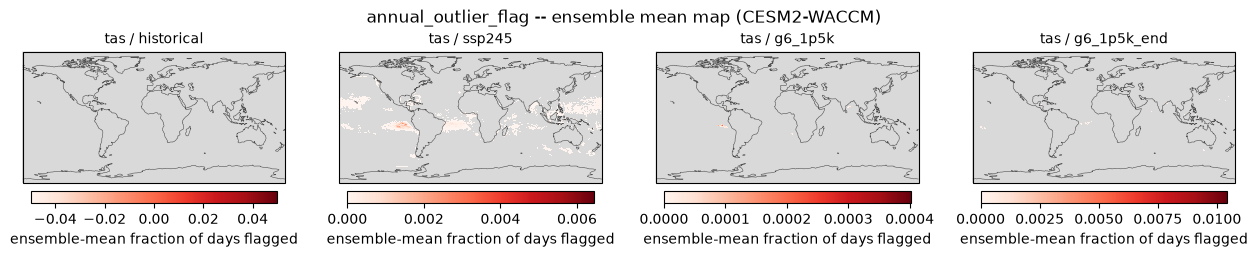

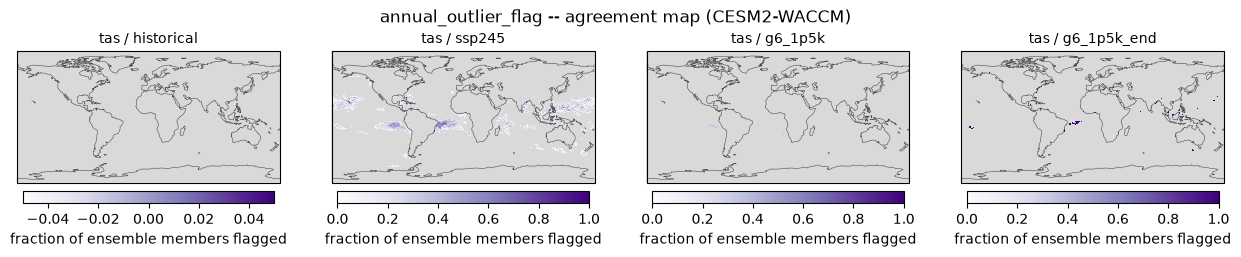

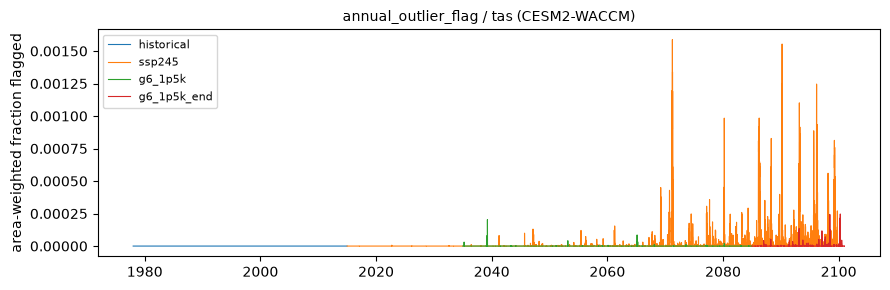

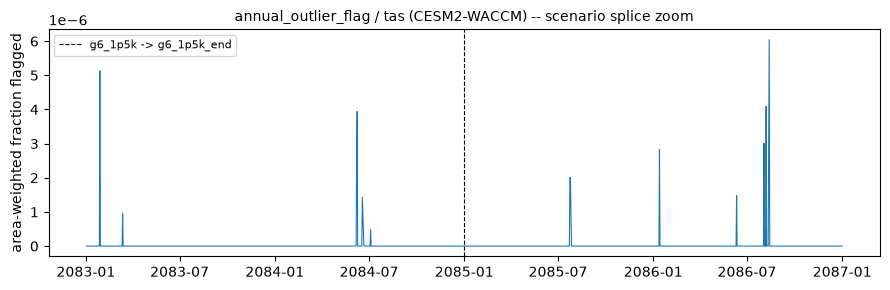

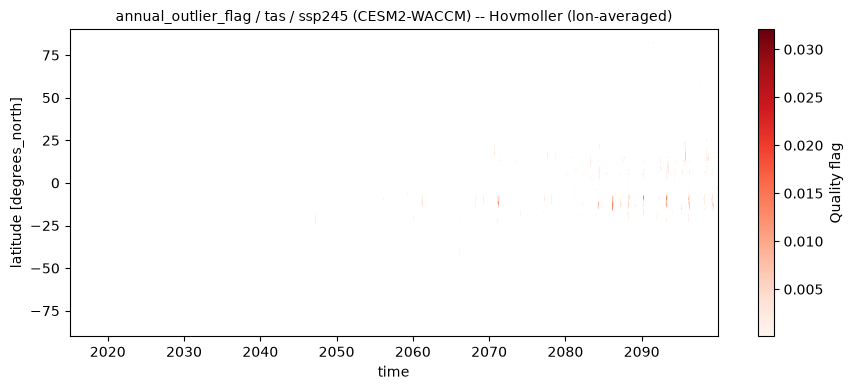

,lat,lon,value
0,13.25,100.25,0.006443
1,13.25,100.50,0.005106
2,7.75,123.75,0.004082
3,-9.75,-89.00,0.003059
4,-10.00,-88.75,0.002930
5,-10.00,-89.00,0.002871
6,-9.00,-93.25,0.002846
7,-9.75,-88.75,0.002831
8,-10.00,-88.50,0.002798
9,-9.50,-89.50,0.002785


In [19]:
# variables=[PREVIEW_VARIABLE] matters here: the full catalog has every variable for this
# flag, but only PREVIEW_VARIABLE has actually been computed above.
plot_flag_grid(
    PREVIEW_FLAG_NAME, PREVIEW_GCM, field="ensemble_mean_map", variables=[PREVIEW_VARIABLE]
)
plt.show()

plot_flag_grid(
    PREVIEW_FLAG_NAME,
    PREVIEW_GCM,
    field="agreement_map",
    variables=[PREVIEW_VARIABLE],
    cmap=PLOT_STYLE["cmap_agreement"],
)
plt.show()

plot_timeseries(PREVIEW_FLAG_NAME, PREVIEW_GCM, PREVIEW_VARIABLE)
plt.show()

plot_boundary_zoom(PREVIEW_FLAG_NAME, PREVIEW_GCM, PREVIEW_VARIABLE)
plt.show()

plot_hovmoller(PREVIEW_FLAG_NAME, PREVIEW_GCM, PREVIEW_VARIABLE, "ssp245")
plt.show()

if preview_ti_combos:
    plot_time_invariant_grid(
        PREVIEW_GCM, flags=[PREVIEW_TI_FLAG_NAME], variables=[PREVIEW_VARIABLE]
    )
    plt.show()

show_top_n(PREVIEW_FLAG_NAME, PREVIEW_GCM, PREVIEW_VARIABLE, scenario="ssp245", n=10)

If these look like the right thing to be evaluating, continue on to **Full run** below.
If not, change the `PREVIEW_*` variables above and re-run this section -- e.g. try a
different flag from `FLAG_LIST_TIME_VARYING`/`FLAG_LIST_TIME_INVARIANT`, or a variable more
likely to show something interesting.

---
# Full run

Computes and plots **one flag at a time**: every `(variable, scenario)` combo for a flag is
computed first, then that flag's figures (map grid, agreement grid, summary heatmap, time
series, boundary zoom, Hovmoller) are generated and saved immediately, before moving on to
the next flag. That way figures for flag 1 are already sitting in `FIGURE_DIR` while flag 2
is still computing, instead of everything landing only once all ~96 combos are done.
Anything already cached from the Quick preview above is a fast cache hit here (reloaded
from `CACHE_DIR`, not recomputed).

Figures are **saved but not displayed inline** -- rendering ~250 images into the notebook's
own output would make the .ipynb file itself huge. Look at the PNGs in `FIGURE_DIR`
directly as they land, rather than waiting on this notebook. A progress bar tracks combos
completed out of the total; it won't move at a constant rate, since `historical` and
`ssp245` combos (the two long scenarios) take noticeably longer per combo than
`g6_1p5k_end` -- their `ensemble_mean_hovmoller` array alone is ~10-40x bigger, and it's
computed in the same `dask.compute()` call as the map for efficiency (see "Helper
functions" above), making up roughly 90% of everything that ends up in `CACHE_DIR`.

`summary_table.csv` in `CACHE_DIR` is rewritten after every flag too, so it reflects
whatever's been computed so far, not just the final state once everything finishes.

In [20]:
time_varying_results = {}
time_invariant_results = {}
summary_rows = []

In [21]:
print(FLAG_LIST_TIME_VARYING)

['annual_outlier_flag', 'rsds_max_exceeded', 'outside_global_plausible_range', 'temperature_inconsistency']


In [22]:
print(FLAG_LIST_TIME_INVARIANT)

['flipped_sign_ssp245_g6_1p5k', 'flipped_sign_historical_ssp245', 'flipped_sign_historical_g6_1p5k', 'trend_distortion_historical_ssp245', 'trend_distortion_ssp245_g6_1p5k', 'trend_distortion_historical_g6_1p5k', 'flipped_sign_g6_1p5k_g6_1p5k_end', 'trend_distortion_g6_1p5k_g6_1p5k_end']


In [ ]:
for flag_name in FLAG_LIST_TIME_VARYING:
    print(flag_name)
    for gcm in GCMS:
        flag_combos = [
            c for c in time_varying_combos if c["flag_name"] == flag_name and c["gcm"] == gcm
        ]
        if not flag_combos:
            continue

        for combo in flag_combos:
            key = _combo_key(combo)
            res = compute_or_load(key, lambda combo=combo: _compute_time_varying_combo(combo))
            time_varying_results[key] = res
            pmt = res["per_member_table"]
            summary_rows.append(
                {
                    "flag_type": "time_varying",
                    "flag_name": combo["flag_name"],
                    "gcm": combo["gcm"],
                    "variable": combo["variable"],
                    "scenario": combo["scenario"],
                    "n_members": len(pmt),
                    "ensemble_mean_frac_flagged": float(pmt["frac_flagged"].mean()),
                    "ensemble_mean_frac_space_ever_flagged": float(
                        pmt["frac_space_ever_flagged"].mean()
                    ),
                    "ensemble_mean_frac_flagged_land": float(pmt["frac_flagged_land"].mean()),
                }
            )

        # every (variable, scenario) combo for this flag is computed -- plot and save now,
        # instead of waiting for every other flag to finish too
        summary_df = pd.DataFrame(summary_rows)

        fig = plot_flag_grid(flag_name, gcm, field="ensemble_mean_map")
        fig.savefig(FIGURE_DIR / f"map_{flag_name}_{gcm}.png", dpi=150)
        plt.close(fig)

        fig = plot_flag_grid(
            flag_name, gcm, field="agreement_map", cmap=PLOT_STYLE["cmap_agreement"]
        )
        fig.savefig(FIGURE_DIR / f"agreement_{flag_name}_{gcm}.png", dpi=150)
        plt.close(fig)

        fig = plot_summary_heatmap(flag_name, gcm)
        fig.savefig(FIGURE_DIR / f"summary_heatmap_{flag_name}_{gcm}.png", dpi=150)
        plt.close(fig)

        for var in VARIABLES:
            fig = plot_timeseries(flag_name, gcm, var)
            fig.savefig(FIGURE_DIR / f"timeseries_{flag_name}_{var}_{gcm}.png", dpi=150)
            plt.close(fig)

            fig = plot_boundary_zoom(flag_name, gcm, var)
            if fig is not None:
                fig.savefig(FIGURE_DIR / f"boundary_zoom_{flag_name}_{var}_{gcm}.png", dpi=150)
                plt.close(fig)

            for scn in SCENARIO_ORDER:
                fig = plot_hovmoller(flag_name, gcm, var, scn)
                if fig is not None:
                    fig.savefig(
                        FIGURE_DIR / f"hovmoller_{flag_name}_{var}_{scn}_{gcm}.png", dpi=150
                    )
                    plt.close(fig)

        summary_df.to_csv(f"{CACHE_DIR}/summary_table.csv", index=False)  # progressively updated

In [24]:
for flag_name in FLAG_LIST_TIME_INVARIANT:
    for gcm in GCMS:
        flag_combos = [
            c for c in time_invariant_combos if c["flag_name"] == flag_name and c["gcm"] == gcm
        ]
        if not flag_combos:
            continue

        for combo in flag_combos:
            key = _ti_combo_key(combo)
            res = compute_or_load(key, lambda combo=combo: _compute_time_invariant_combo(combo))
            time_invariant_results[key] = res
            summary_rows.append(
                {
                    "flag_type": "time_invariant",
                    "flag_name": combo["flag_name"],
                    "gcm": combo["gcm"],
                    "variable": combo["variable"],
                    "scenario": None,
                    "n_members": None,
                    "ensemble_mean_frac_flagged": res["frac_flagged"],
                    "ensemble_mean_frac_space_ever_flagged": None,
                    "ensemble_mean_frac_flagged_land": res["frac_flagged_land"],
                }
            )

        summary_df = pd.DataFrame(summary_rows)
        fig = plot_time_invariant_grid(gcm, flags=[flag_name])
        fig.savefig(FIGURE_DIR / f"time_invariant_map_{flag_name}_{gcm}.png", dpi=150)
        plt.close(fig)
        summary_df.to_csv(f"{CACHE_DIR}/summary_table.csv", index=False)

summary_df  # final, complete summary table

,flag_type,flag_name,gcm,variable,scenario,n_members,ensemble_mean_frac_flagged,ensemble_mean_frac_space_ever_flagged,ensemble_mean_frac_flagged_land
0,time_varying,annual_outlier_flag,CESM2-WACCM,pr,g6_1p5k,3.0,1.509982e-06,0.020476,6.484459e-07
1,time_varying,annual_outlier_flag,CESM2-WACCM,pr,g6_1p5k_end,1.0,1.436758e-06,0.007316,1.119616e-06
2,time_varying,annual_outlier_flag,CESM2-WACCM,pr,historical,3.0,3.782162e-08,0.000226,1.113284e-07
3,time_varying,annual_outlier_flag,CESM2-WACCM,pr,ssp245,10.0,1.924706e-06,0.035390,9.604966e-07
4,time_varying,annual_outlier_flag,CESM2-WACCM,rsds,g6_1p5k,3.0,5.505964e-06,0.001943,1.023688e-05
...,...,...,...,...,...,...,...,...,...
66,time_invariant,trend_distortion_g6_1p5k_g6_1p5k_end,CESM2-WACCM,pr,NaN,NaN,3.767934e-01,NaN,5.002807e-01
67,time_invariant,trend_distortion_g6_1p5k_g6_1p5k_end,CESM2-WACCM,rsds,NaN,NaN,3.035368e-01,NaN,3.107373e-01
68,time_invariant,trend_distortion_g6_1p5k_g6_1p5k_end,CESM2-WACCM,tas,NaN,NaN,4.997785e-02,NaN,4.775823e-02
69,time_invariant,trend_distortion_g6_1p5k_g6_1p5k_end,CESM2-WACCM,tasmax,NaN,NaN,4.402643e-03,NaN,5.516467e-03


## Top-N worst-offender pixels (example)

Cheap lookups from the already-cached ensemble-mean maps -- adjust the flag/variable/
scenario/`n` below for whichever cell in the grid figures above looks worth drilling
into.

In [25]:
show_top_n(
    flag_name=FLAG_LIST_TIME_VARYING[0], gcm=GCMS[0], var=VARIABLES[0], scenario="ssp245", n=15
)

,lat,lon,value
0,13.25,100.25,0.006443
1,13.25,100.50,0.005106
2,7.75,123.75,0.004082
3,-9.75,-89.00,0.003059
4,-10.00,-88.75,0.002930
5,-10.00,-89.00,0.002871
6,-9.00,-93.25,0.002846
7,-9.75,-88.75,0.002831
8,-10.00,-88.50,0.002798
9,-9.50,-89.50,0.002785


## Shut down the cluster

In [ ]:
client.close()
cluster.close()